# Taller de Detección de Formas y Métricas Geométricas con OpenCV

## Instalación de dependencias

In [5]:
%pip install opencv-python numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Importar librerias

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Generar imagen sintética con formas geométricas

Se genera una imagen en blanco de 700×700 px con 9 figuras: 3 círculos, 3 cuadrados o rectángulos y 3 triángulos. 

Esto garantiza que el notebook sea completamente autocontenido sin depender de imágenes externas. 

Cada figura tiene tamaño distinto para demostrar la variación en las métricas calculadas.

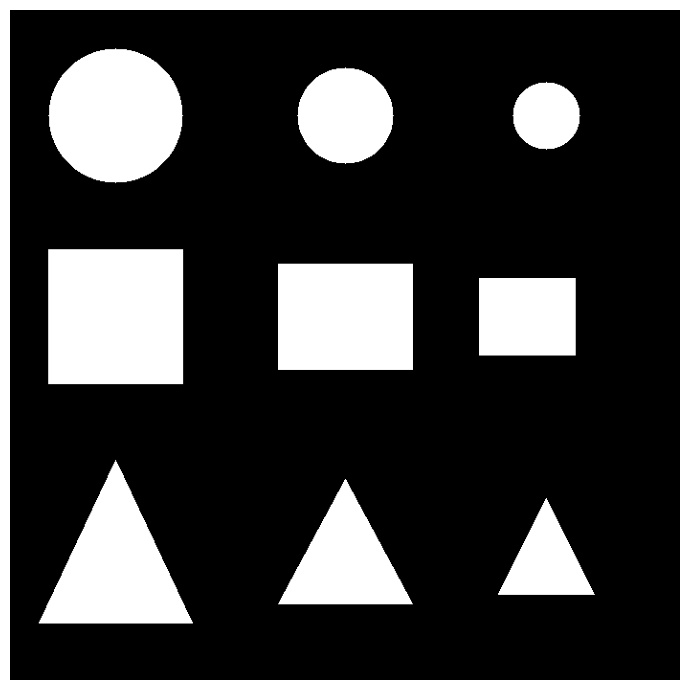

In [11]:
H, W = 700, 700
img_original = np.zeros((H, W, 3), dtype=np.uint8)

# Círculos
cv2.circle(img_original, (110, 110), 70,  (255, 255, 255), -1)  
cv2.circle(img_original, (350, 110), 50,  (255, 255, 255), -1) 
cv2.circle(img_original, (560, 110), 35,  (255, 255, 255), -1)  

# Cuadrados / Rectángulos
cv2.rectangle(img_original, (40,  250), (180, 390), (255, 255, 255), -1)  
cv2.rectangle(img_original, (280, 265), (420, 375), (255, 255, 255), -1) 
cv2.rectangle(img_original, (490, 280), (590, 360), (255, 255, 255), -1)  

# Triángulos
tri1 = np.array([[110, 470], [30,  640], [190, 640]], np.int32)
tri2 = np.array([[350, 490], [280, 620], [420, 620]], np.int32)
tri3 = np.array([[560, 510], [510, 610], [610, 610]], np.int32)
cv2.fillPoly(img_original, [tri1], (255, 255, 255))
cv2.fillPoly(img_original, [tri2], (255, 255, 255))
cv2.fillPoly(img_original, [tri3], (255, 255, 255))

cv2.imwrite('../media/imagen_original.png', img_original)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Binarización con cv2.threshold()

Se convierte la imagen a escala de grises y se aplica umbral binario con `cv2.THRESH_BINARY`. Dado que la imagen ya es blanco/negro, el resultado es equivalente. 

Se muestra el histograma de intensidades para evidenciar la distribución bimodal característica de una imagen binarizada.

Umbral aplicado: 127.0
Píxeles blancos (figuras): 99,087
Píxeles negros (fondo):    390,913


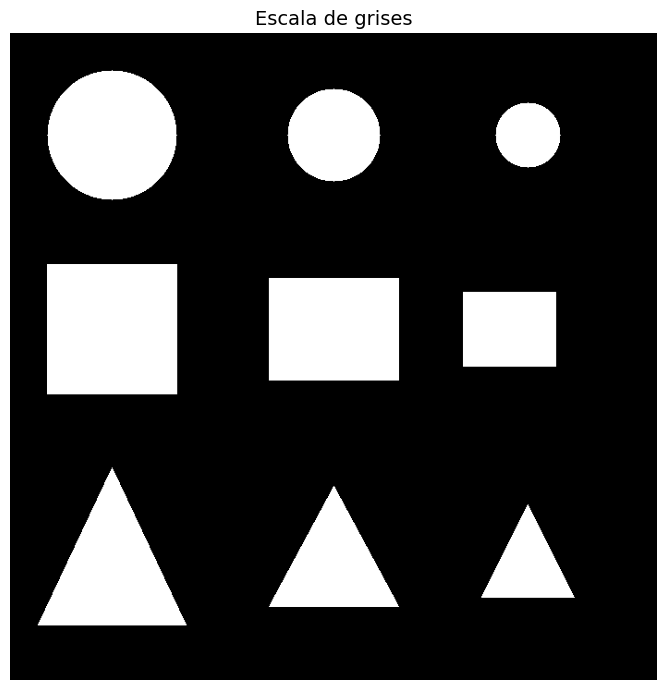

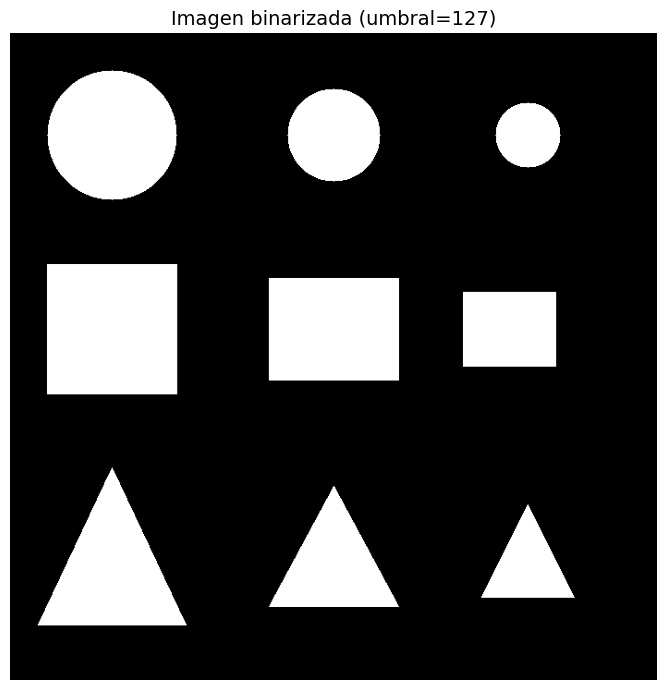

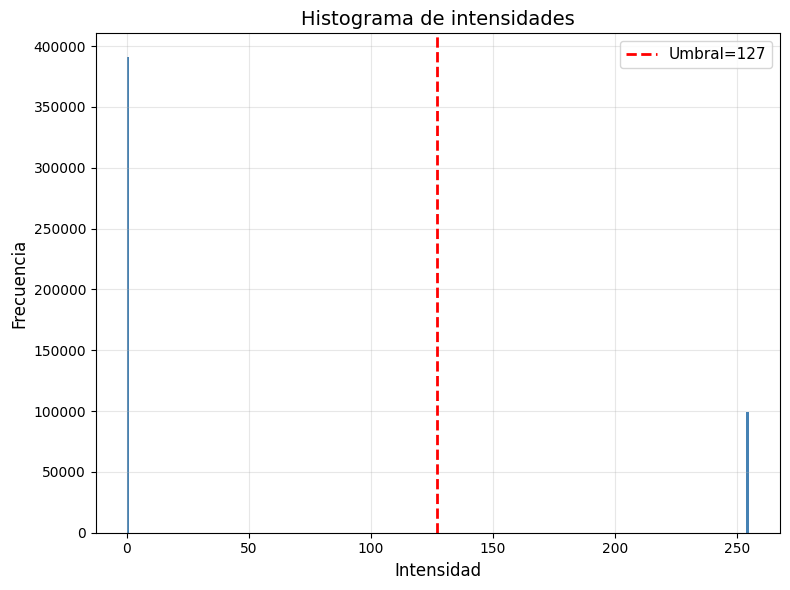

In [24]:
# Conversion a gris
img_gray = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

# Binarizar con umbral 127
ret, img_bin = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
print(f'Umbral aplicado: {ret}')
print(f'Píxeles blancos (figuras): {np.sum(img_bin == 255):,}')
print(f'Píxeles negros (fondo):    {np.sum(img_bin == 0):,}')

# Escala de grises
plt.figure(figsize=(7, 7))
plt.imshow(img_gray, cmap='gray')
plt.title('Escala de grises', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/paso2_binarizacion1.png', dpi=150, bbox_inches='tight')
plt.show()

# Imagen binarizada
plt.figure(figsize=(7, 7))
plt.imshow(img_bin, cmap='gray')
plt.title(f'Imagen binarizada (umbral={int(ret)})', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/paso2_binarizacion2.png', dpi=150, bbox_inches='tight')
plt.show()

# Histograma de intensidades
plt.figure(figsize=(8, 6))
plt.hist(img_gray.ravel(), bins=256, color='steelblue', edgecolor='none')
plt.axvline(ret, color='red', linestyle='--', linewidth=2, label=f'Umbral={int(ret)}')
plt.title('Histograma de intensidades', fontsize=14)
plt.xlabel('Intensidad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../media/paso2_binarizacion3.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Detección de contornos con cv2.findContours()

`cv2.RETR_EXTERNAL` recupera solo los contornos más externos. 
`cv2.CHAIN_APPROX_SIMPLE` comprime segmentos horizontales, verticales y diagonales almacenando solo sus puntos extremos, reduciendo el número de puntos del contorno.

   Contorno 1: 201 puntos, área aprox. 5000 px²
   Contorno 2: 243 puntos, área aprox. 9100 px²
   Contorno 3: 323 puntos, área aprox. 13600 px²
   Contorno 4: 4 puntos, área aprox. 8000 px²
   Contorno 5: 4 puntos, área aprox. 15400 px²
   Contorno 6: 4 puntos, área aprox. 19600 px²
   Contorno 7: 100 puntos, área aprox. 3754 px²
   Contorno 8: 148 puntos, área aprox. 7704 px²
   Contorno 9: 196 puntos, área aprox. 15176 px²


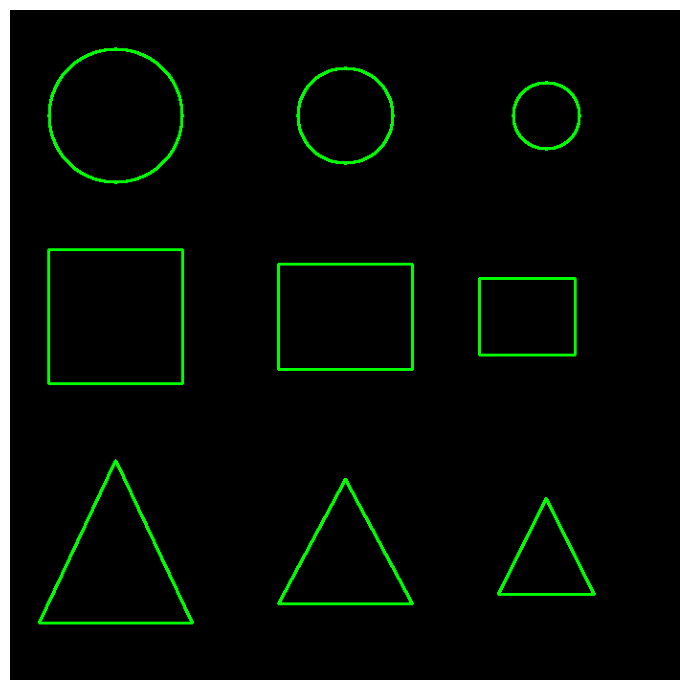

In [13]:
contours, hierarchy = cv2.findContours(
    img_bin,
    cv2.RETR_EXTERNAL,        # solo contornos externos
    cv2.CHAIN_APPROX_SIMPLE   # comprimir segmentos rectos
)

MIN_AREA = 300
contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]

for i, c in enumerate(contours):
    print(f'   Contorno {i+1}: {len(c)} puntos, área aprox. {cv2.contourArea(c):.0f} px²')

img_contornos = np.zeros_like(img_original)
cv2.drawContours(img_contornos, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.savefig('../media/paso3_contornos.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Calcular propiedades geométricas

Para cada contorno se calculan:
- **Área**: `cv2.contourArea()`para el número de píxeles dentro del contorno.
- **Perímetro**: `cv2.arcLength(c, True)` para la longitud total del contorno cerrado.
- **Centroide**: a partir de los momentos `cv2.moments()` con `cx = M10/M00`, `cy = M01/M00`.
- **Circularidad**: `4π × área / perímetro²` donde valor 1.0 es círculo perfecto.

In [19]:
metricas = []

for i, c in enumerate(contours):
    area      = cv2.contourArea(c) # Area
    perimetro = cv2.arcLength(c, True) # Perímetro
    M         = cv2.moments(c)

    # Centroide (sin division por cero)
    if M['m00'] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
    else:
        cx, cy = 0, 0

    # Circularidad: 1.0 es círculo perfecto
    circularidad = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0

    x, y, w, h = cv2.boundingRect(c)
    aspect_ratio = float(w) / h if h > 0 else 0

    metricas.append({
        'id':           i + 1,
        'contour':      c,
        'area':         area,
        'perimetro':    perimetro,
        'cx':           cx,
        'cy':           cy,
        'circularidad': circularidad,
        'aspect_ratio': aspect_ratio,
    })

print(f'{'ID':>3} | {'Área':>8} | {'Perímetro':>10} | {'Centroide':>14} | {'Circular (Decimal)':>10}')
print('-' * 65)
for m in metricas:
    print(f"{m['id']:>3} | {m['area']:>8.1f} | {m['perimetro']:>10.2f} | "
          f"({m['cx']:>3},{m['cy']:>3}){' ':>5} | {m['circularidad']:>10.4f}")


 ID |     Área |  Perímetro |      Centroide | Circular (Decimal)
-----------------------------------------------------------------
  1 |   5000.0 |     341.42 | (559,576)      |     0.5390
  2 |   9100.0 |     457.99 | (350,576)      |     0.5452
  3 |  13600.0 |     566.27 | (110,583)      |     0.5330
  4 |   8000.0 |     360.00 | (540,320)      |     0.7757
  5 |  15400.0 |     500.00 | (350,320)      |     0.7741
  6 |  19600.0 |     560.00 | (110,320)      |     0.7854
  7 |   3754.0 |     230.79 | (560,110)      |     0.8856
  8 |   7704.0 |     329.71 | (350,110)      |     0.8906
  9 |  15176.0 |     461.59 | (110,110)      |     0.8951


## **BONUS**: Clasificación automática con cv2.approxPolyDP()

`cv2.approxPolyDP()` aproxima el contorno a un polígono con menor número de vértices usando el algoritmo de Ramer-Douglas-Peucker. 

El parámetro epsilon controla la tolerancia: a mayor epsilon, menos vértices. Contando los vértices del polígono aproximado se clasifica la figura: 3 → triángulo, 4 → cuadrado/rectángulo, ≥8 → círculo.

In [22]:
def clasificar_figura(contour, circularidad, aspect_ratio):
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx  = cv2.approxPolyDP(contour, epsilon, True)
    n_verts = len(approx)

    if n_verts == 3:
        return 'Triángulo', n_verts, approx
    elif n_verts == 4:
        # Diferenciar cuadrado de rectángulo por aspect ratio
        if 0.85 <= aspect_ratio <= 1.15:
            return 'Cuadrado', n_verts, approx
        else:
            return 'Rectángulo', n_verts, approx
    elif n_verts >= 8 or circularidad > 0.80:
        return 'Círculo', n_verts, approx
    else:
        return f'Polígono ({n_verts}v)', n_verts, approx

for m in metricas:
    figura, n_verts, approx = clasificar_figura(
        m['contour'], m['circularidad'], m['aspect_ratio']
    )
    m['figura']  = figura
    m['n_verts'] = n_verts
    m['approx']  = approx

print(f"{'ID':>3} | {'Figura':>12} | {'Vértices':>8} | {'Circularidad':>12}")
print('-' * 45)
for m in metricas:
    print(f"{m['id']:>3} | {m['figura']:>12} | {m['n_verts']:>8} | {m['circularidad']:>12.4f}")

 ID |       Figura | Vértices | Circularidad
---------------------------------------------
  1 |    Triángulo |        3 |       0.5390
  2 |    Triángulo |        3 |       0.5452
  3 |    Triángulo |        3 |       0.5330
  4 |   Rectángulo |        4 |       0.7757
  5 |   Rectángulo |        4 |       0.7741
  6 |     Cuadrado |        4 |       0.7854
  7 |      Círculo |        8 |       0.8856
  8 |      Círculo |        8 |       0.8906
  9 |      Círculo |        8 |       0.8951


## 5. Visualización con métricas etiquetadas

Cada figura se dibuja con su contorno coloreado por tipo, el centroide marcado como punto rojo y una etiqueta con las métricas calculadas. 

El color del contorno identifica visualmente la clasificación: verde para círculos, azul para cuadrados/rectángulos, naranja para triángulos.

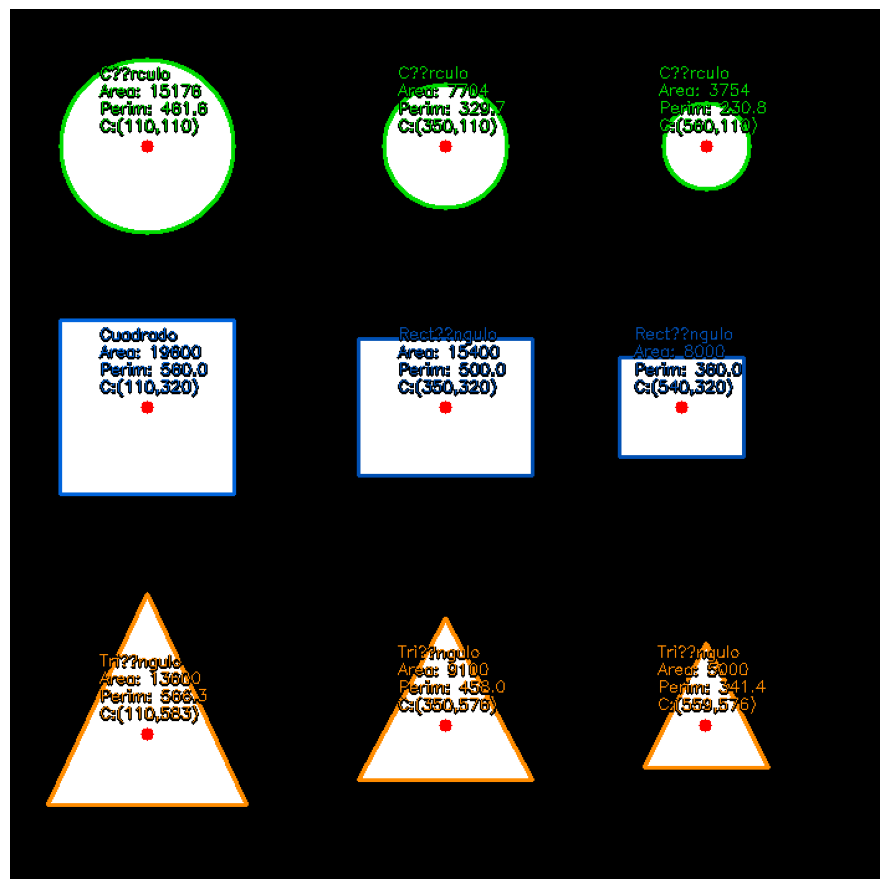

In [ ]:
COLORES = {
    'Círculo':     (0, 220, 0),
    'Cuadrado':    (220, 100, 0),
    'Rectángulo':  (180, 80, 0),
    'Triángulo':   (0, 140, 255),
}
COLOR_DEFAULT = (200, 200, 200)

img_resultado = img_original.copy()

for m in metricas:
    color = COLORES.get(m['figura'], COLOR_DEFAULT)
    cx, cy = m['cx'], m['cy']

    # Dibujar contorno
    cv2.drawContours(img_resultado, [m['contour']], -1, color, 2)

    # Centroide
    cv2.circle(img_resultado, (cx, cy), 5, (0, 0, 255), -1)

    # Etiquetas con métricas
    font       = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.42
    thickness  = 1
    offset_y   = cy - 55

    labels = [
        m['figura'],
        f"Area: {m['area']:.0f}",
        f"Perim: {m['perimetro']:.1f}",
        f"C:({cx},{cy})",
    ]

    for j, text in enumerate(labels):
        y_pos = offset_y + j * 14
        cv2.putText(img_resultado, text,
                    (cx - 38, y_pos + 1), font, font_scale, (0, 0, 0), thickness + 1)
        cv2.putText(img_resultado, text,
                    (cx - 38, y_pos), font, font_scale, color, thickness)

cv2.imwrite('../media/paso4_resultado.png', img_resultado)

plt.figure(figsize=(9, 9))
plt.imshow(cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()